In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
%matplotlib inline
from scipy.optimize import curve_fit
from scipy.optimize import differential_evolution
from scipy import integrate

In [2]:
filename = '3w法.xlsx'

# 読み込みたいシート名だけを書く
target_sheets = [
    "re_300K_20mA",
    "310K_20mA",
    "320K_20mA",
    "330K_20mA",
    "340K_20mA",
    "350K_20mA",
    "360K_20mA",
    "370K_20mA",
    "380K_20mA",
    "390K_20mA",
    "re_400K_20mA",
]

excel_names = {}
temp_map = {}
cur_map = {}

for i, sheet in enumerate(target_sheets, start=1):
    key = f'df_{i}'  
    read = pd.read_excel(filename, sheet)
    excel_names[key] = sheet
    globals()[key] = read 
    
    # 温度(K)の抽出と変数への代入
    match_temp = re.search(r'(\d+)K', sheet)
    temp = int(match_temp.group(1)) if match_temp else "エラー"
    if match_temp:
        temp_map[key] = temp
        
    # 電流(mA)の抽出と変数への代入
    match_cur = re.search(r'(\d+)mA', sheet)
    cur = int(match_cur.group(1)) if match_cur else "エラー"
    if match_cur:
        cur_map[key] = cur

    print(f"{key:6} : {sheet:15} 温度: {temp}K  電流: {cur}mA")
    
print("=== 読み込み完了 ===\n")

df_1   : re_300K_20mA    温度: 300K  電流: 20mA
df_2   : 310K_20mA       温度: 310K  電流: 20mA
df_3   : 320K_20mA       温度: 320K  電流: 20mA
df_4   : 330K_20mA       温度: 330K  電流: 20mA
df_5   : 340K_20mA       温度: 340K  電流: 20mA
df_6   : 350K_20mA       温度: 350K  電流: 20mA
df_7   : 360K_20mA       温度: 360K  電流: 20mA
df_8   : 370K_20mA       温度: 370K  電流: 20mA
df_9   : 380K_20mA       温度: 380K  電流: 20mA
df_10  : 390K_20mA       温度: 390K  電流: 20mA
df_11  : re_400K_20mA    温度: 400K  電流: 20mA
=== 読み込み完了 ===



In [3]:
 #=============================周波数範囲=================================
freq_min = 30.0
freq_max = 10000

#============================データの用いる数=========================
first_number=1
last_number=11
 

average_res = {}
average_Vw = {}
 #平均温抵抗値の定義

print("=== 平均抵抗値 ===")

for i in range(first_number, last_number+1):
    df_name = f'df_{i}'
    current_df = globals().get(df_name)
     #ループでデータすべての平均抵抗値を求める
    if current_df is None:
        print(f"データフレーム '{df_name}' が見つかりませんでした。スキップします。")
         #データがない場合、上を出力
    
        continue

    try:
        current_df['resistance'] = np.abs(current_df['Vomega(V)'])/(cur_map[df_name]*10**-3)
         #扱った電圧から計算したの抵抗値
        filtered_df = current_df[(current_df[' Current_Freq(Hz)'] >= freq_min) & (current_df[' Current_Freq(Hz)'] <= freq_max)]
         #周波数範囲の制限
        
        avg_Vw = np.abs(filtered_df['Vomega(V)']).mean()
        average_Vw[df_name] = avg_Vw
        
        avg_res = filtered_df['resistance'].mean()
         #計算した抵抗値を周波数範囲を考慮して平均化
        average_res[df_name] = avg_res
         #求めた平均抵抗値を辞書に保存
        print(f"{df_name} の平均抵抗値 {avg_res:.10f}")
         #平均抵抗値の出力
        
    
    except KeyError as e:
        print(f"エラー: {df_name} に列 {e} がありません。")
         #データに列がない場合、上を出力
    except Exception as e:
        print(f"エラー: {df_name} で予期せぬエラーが発生しました: {e}")
         #何かしらエラーが起きた時、上を出力

=== 平均抵抗値 ===
df_1 の平均抵抗値 5.3912792502
df_2 の平均抵抗値 5.5604348201
df_3 の平均抵抗値 5.6914584860
df_4 の平均抵抗値 5.8200566688
df_5 の平均抵抗値 5.9522471450
df_6 の平均抵抗値 6.0840121770
df_7 の平均抵抗値 6.2093410903
df_8 の平均抵抗値 6.3459650937
df_9 の平均抵抗値 6.4754445163
df_10 の平均抵抗値 6.6042829132
df_11 の平均抵抗値 6.7378407671


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

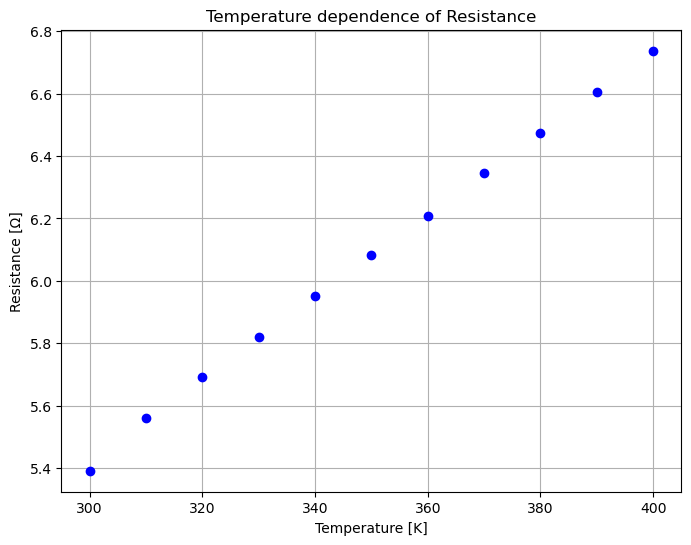

In [4]:
x_temps = []
y_res = []
 # グラフ用のリストを作成

for key, temp in temp_map.items():
    if key in average_res:
        x_temps.append(temp)              # 温度 (横軸)
        y_res.append(average_res[key])    # 抵抗値 (縦軸)
         #temp_mapの順番通りにデータを抽出してリストに追加
        
        plt.figure(figsize=(8, 6)) 
         # グラフのサイズ指定
        
plt.plot(x_temps, y_res, marker='o',  linestyle='None',color='blue') 
 # 折れ線グラフ

plt.xlabel('Temperature [K]')  # 横軸ラベル
plt.ylabel('Resistance [Ω]')   # 縦軸ラベル 
plt.title('Temperature dependence of Resistance') # タイトル
plt.grid(True) # グリッド線を表示

a (傾き)  : 0.01324 +/- 0.00010
b (切片)  : 1.44369 +/- 0.03540
フィッティング式: y = 0.01324x + 1.44369


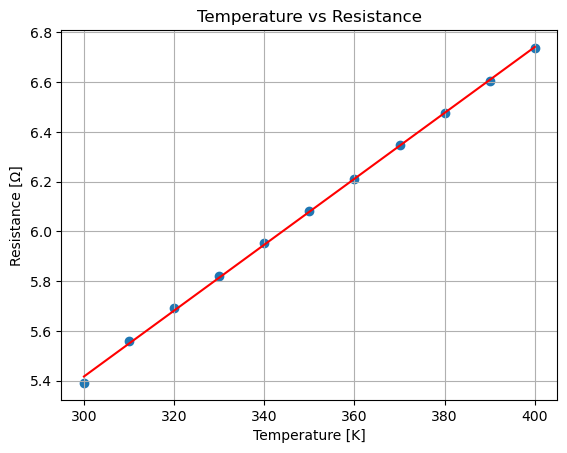

In [5]:
def model(x,a,b):
    return x*a+b
param,cover=curve_fit(model,x_temps,y_res)

a = param[0]
b = param[1]

y_fit=model(np.array(x_temps),param[0],param[1])

perr = np.sqrt(np.diag(cover))
a_err = perr[0] 
b_err = perr[1] 

plt.scatter(np.array(x_temps),y_res)
plt.plot(x_temps,y_fit,color='red')

plt.xlabel('Temperature [K]')  
plt.ylabel('Resistance [Ω]')  
plt.title('Temperature vs Resistance') 
plt.grid(True)

print(f"a (傾き)  : {a:.5f} +/- {a_err:.5f}")
print(f"b (切片)  : {b:.5f} +/- {b_err:.5f}")
print(f"フィッティング式: y = {a:.5f}x + {b:.5f}")

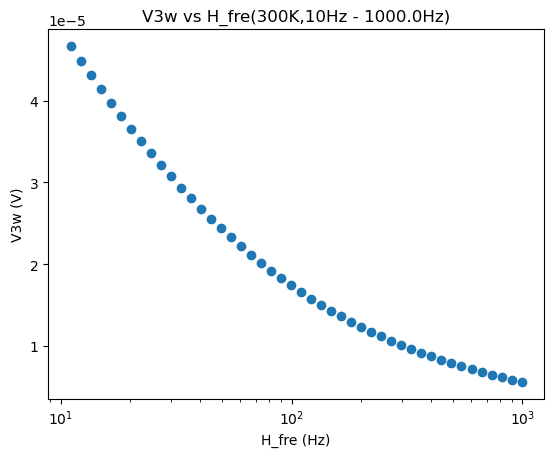

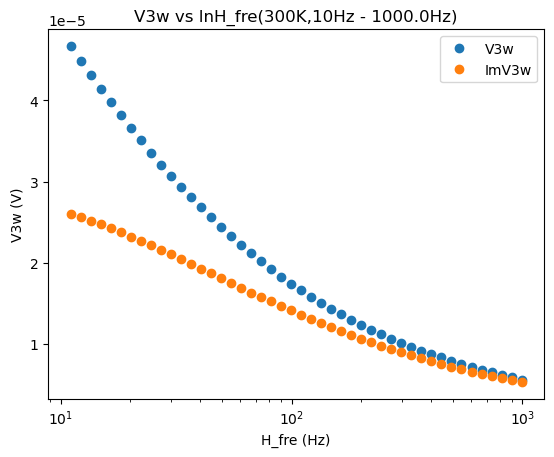

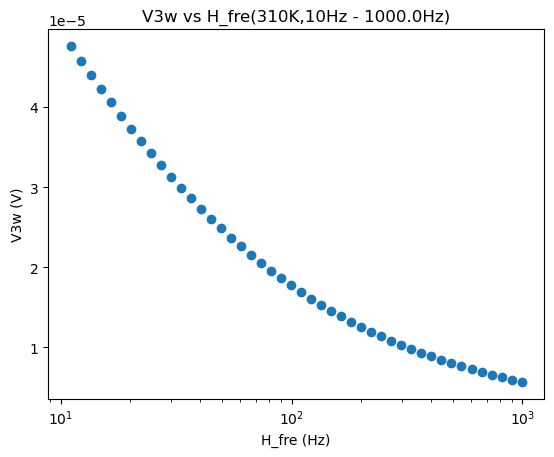

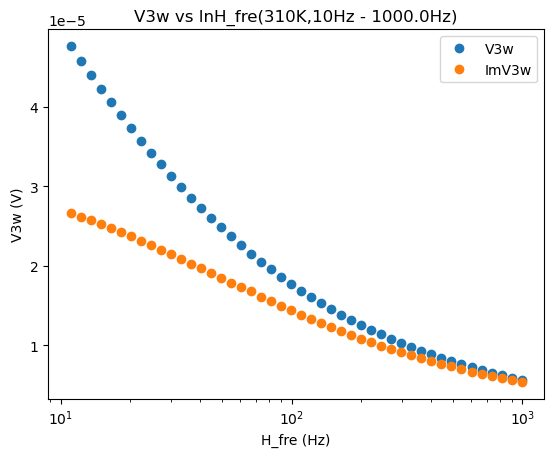

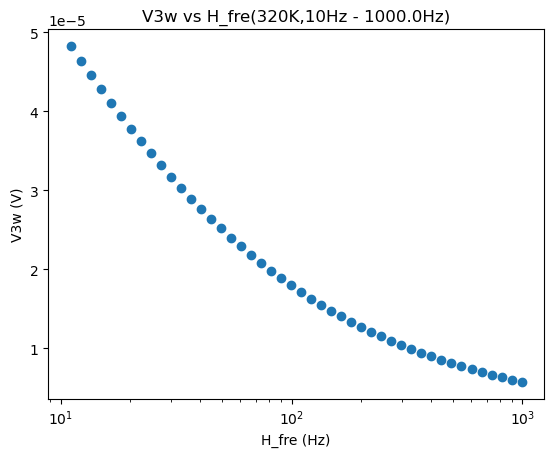

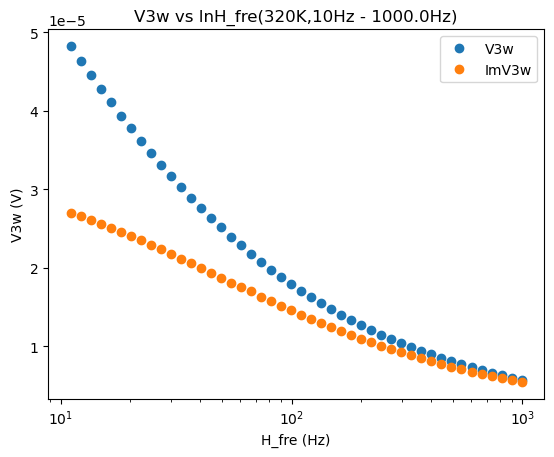

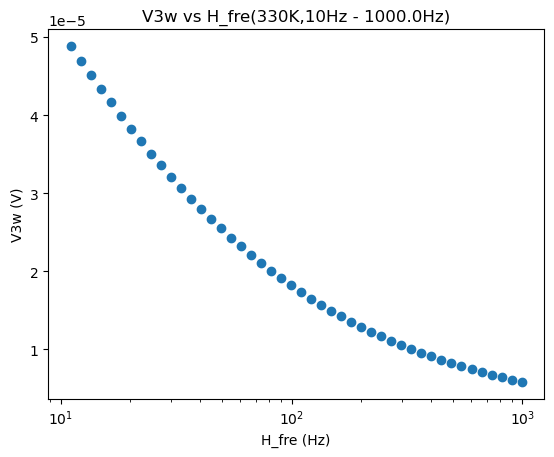

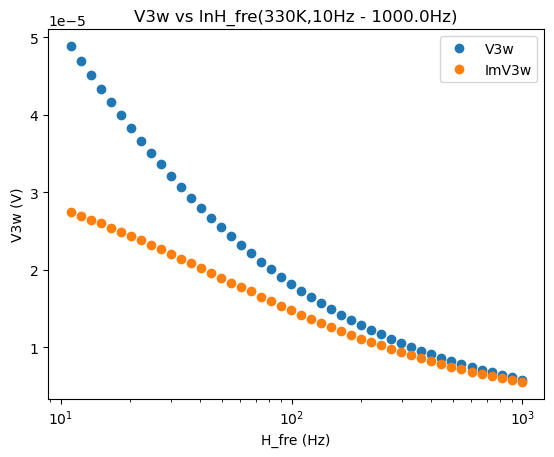

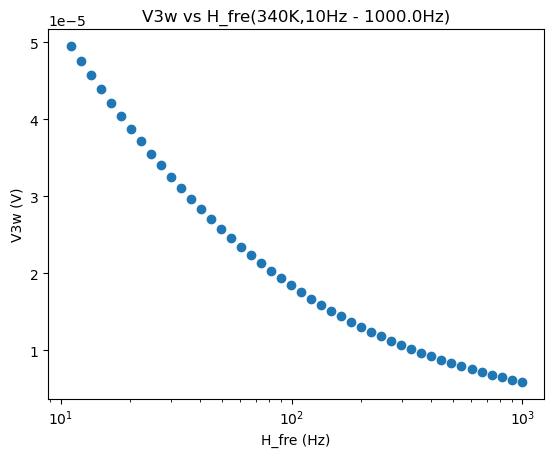

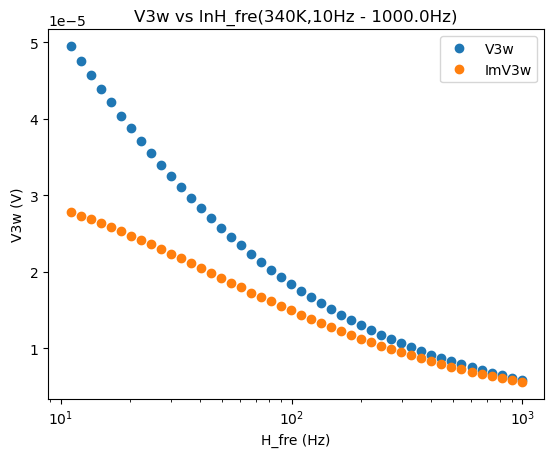

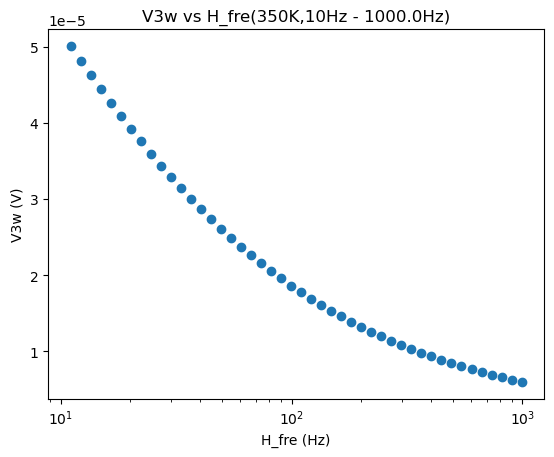

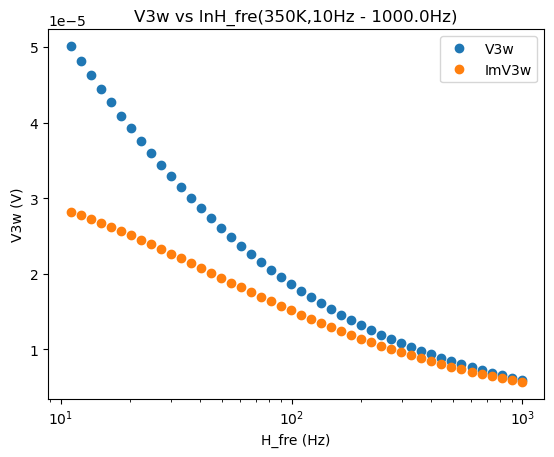

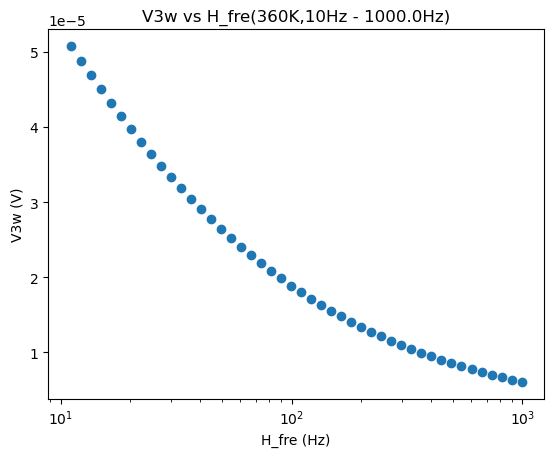

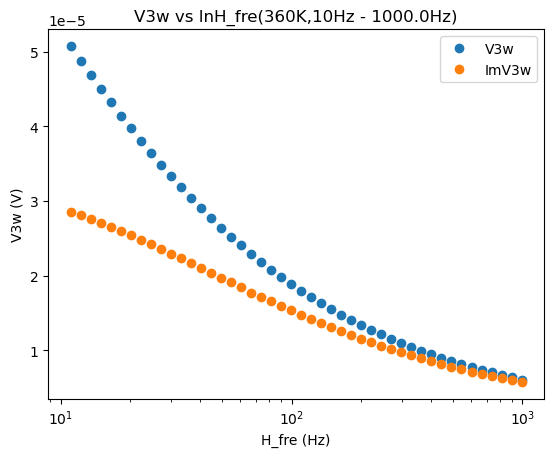

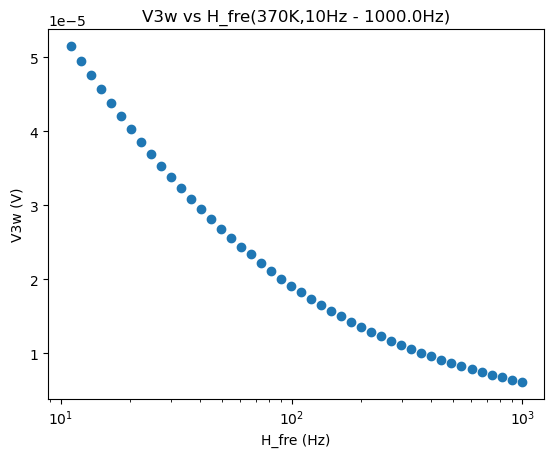

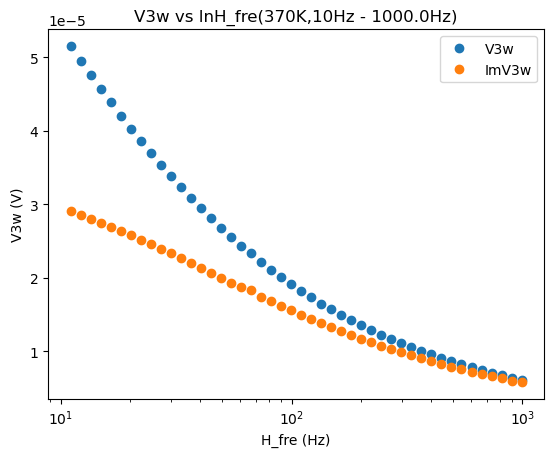

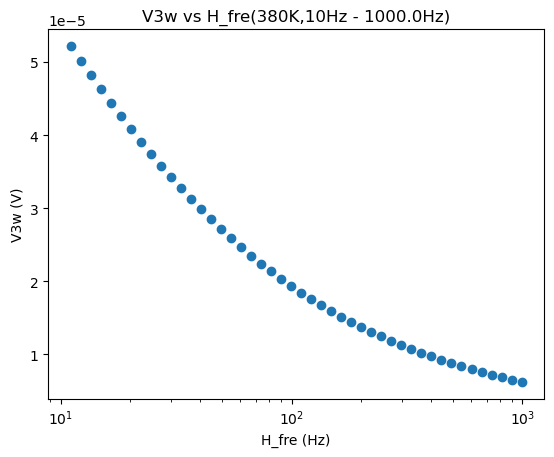

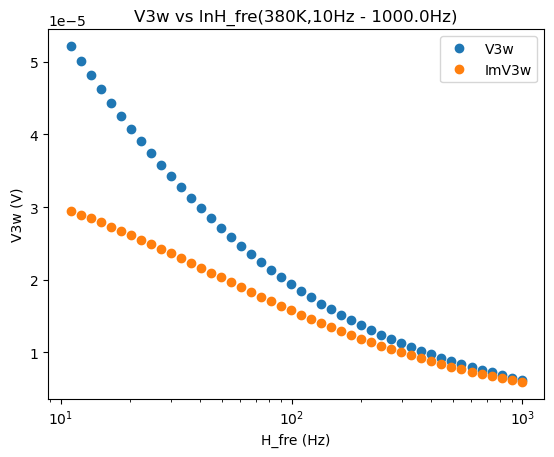

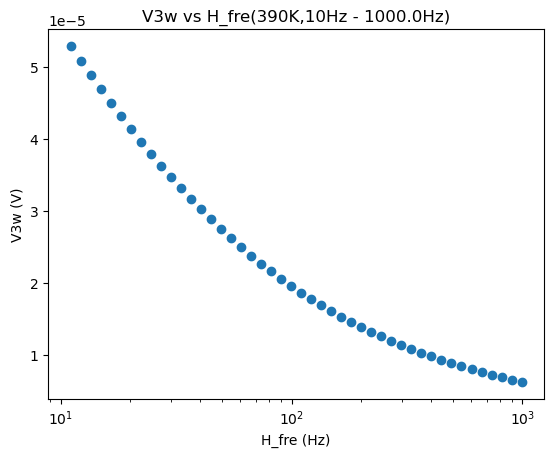

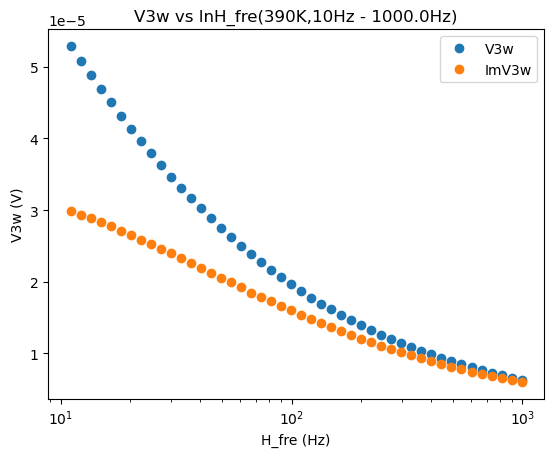

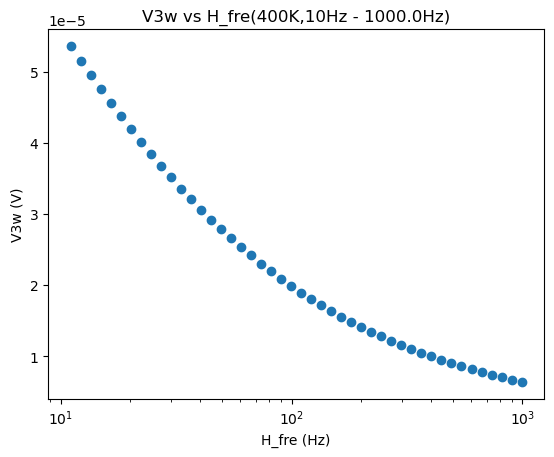

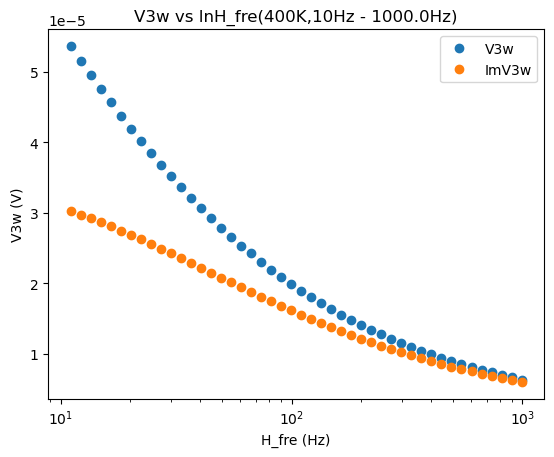

In [6]:
 #==================データの用いる数,範囲=======================
first_number=1
last_number=11

freq_min = 10
freq_max = 1000.0

for i in range(first_number, last_number+1):
    df_name = f'df_{i}'
    current_df = globals().get(df_name)
     #ループでデータすべてのグラフを求める
    if current_df is None:
        print(f"データフレーム '{df_name}' が見つかりませんでした。スキップします。")
         #データがない場合、上を出力
        
        continue
    filtered_df = current_df[(current_df[' Current_Freq(Hz)'] >= freq_min) & (current_df[' Current_Freq(Hz)'] <= freq_max)]
    try:
        plt.figure()
         #新しいグラフ描画の作成
        x = filtered_df[' Current_Freq(Hz)']
        y = np.abs(filtered_df['V3omega(V)'])
        ImV3w=np.abs(filtered_df[' ImV3omega(V)']) 
        plt.plot(x, y, marker='o',  linestyle='None')
        plt.title(f'V3w vs H_fre({temp_map[df_name]}K,{freq_min}Hz - {freq_max}Hz)')
        plt.xlabel('H_fre (Hz)')
        plt.ylabel('V3w (V)')
        plt.xscale('log')
        #タイトル、軸ラベルを記入
        plt.show()
        #グラフの出力
        
        plt.plot(x, y, marker='o',  linestyle='None',label='V3w')
        plt.plot(x, ImV3w, marker='o',  linestyle='None',label='ImV3w')
        plt.title(f'V3w vs lnH_fre({temp_map[df_name]}K,{freq_min}Hz - {freq_max}Hz)')
        plt.xlabel('H_fre (Hz)')
        plt.ylabel('V3w (V)')       
        plt.xscale('log')
        plt.legend()
    except KeyError as e:
        print(f"エラー: {df_name} に列 {e} がありません。")
         #データに列がない場合、上を出力
    except Exception as e:
        print(f"エラー: {df_name} で予期せぬエラーが発生しました: {e}")
         #何かしらエラーが起きた時、上を出力を出力

Differential Evolution を実行中
 推定初期値 -> Kappa=1.1277, Cp=2.1503
Curve Fitを実行中

Kappa: 1.11073e+00 +/- 3.08645e-03 [W/mK]
Cp   : 2.21809e+00 +/- 9.69139e-03 [J/cm^3 K]


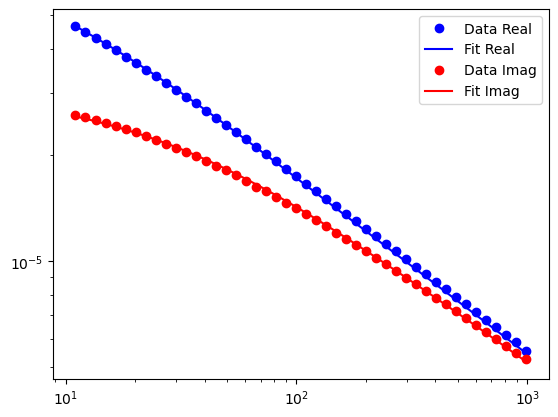

In [7]:
# ====================================================================================
# 物理パラメータの設定
# ====================================================================================
target_df_name = 'df_1'           # 解析対象のデータフレーム名 
L = 2.010 * 10**-3                # 金属膜の長さ [m] 
b = 5.25 * 10**-5                 # 金属膜の幅の半分 [m] 
dR_dT = param[0]                  # 電気抵抗の温度係数

# 単位長さあたりの供給電力 P/L [W/m]
PL = ((cur_map[target_df_name] * 10**-3)**2) * (average_res[target_df_name]) / L

# 基準となる電圧成分の計算
V_2R = (average_Vw[target_df_name]) / (2 * (average_res[target_df_name]))

# 3ω法 理論モデル関数の定義
def V3w_fitting_model(freq_array, kappa, cp_cm):

    cp = cp_cm * 1e6  # 単位変換: J/cm^3 -> J/m^3 
    model_output_complex = []

    for freq in freq_array:
        val_PL = PL / (np.pi * kappa)
        val_f = (1 / (2 * np.pi)) * (kappa / cp)
        q = np.sqrt((2 * freq / val_f) * 1j)  # 熱拡散長に関連するパラメータ 
        
        # 無次元化パラメータ psi を追加
        psi = q * b  
        # 被積分関数
        def get_integrand_val(phi):
            if phi < 1e-8: return (1.0 / psi)  # 近似
            denom = (phi**2) * np.sqrt(phi**2 + psi**2)
            return (np.sin(phi))**2 / denom  
            
        def integrand_real(phi): return np.real(get_integrand_val(phi))
        def integrand_imag(phi): return np.imag(get_integrand_val(phi))

        # 数値積分を実部と虚部を別々に計算
        res_real, _ = integrate.quad(integrand_real, 1e-8, 100, limit=1000)
        res_imag, _ = integrate.quad(integrand_imag, 1e-8, 100, limit=1000)
        
        F_phi = res_real + 1j * res_imag
        V3w_val = val_PL * F_phi * dR_dT * V_2R  # 理論式の完成
        model_output_complex.append(V3w_val)

    model_output_complex = np.array(model_output_complex)
    # curve_fitが1つの配列しか受け取れないため実部と虚部を1列に結合して返す
    return np.hstack([np.real(model_output_complex), np.abs(np.imag(model_output_complex))])


# 実験データの読み込み
current_df = globals()[target_df_name].copy()

# 指定した周波数範囲
filtered_df = current_df[(current_df[' Current_Freq(Hz)'] >= freq_min) & 
                          (current_df[' Current_Freq(Hz)'] <= freq_max)]

freq_data = filtered_df[' Current_Freq(Hz)'].values
V3w_data_real = np.abs(filtered_df['V3omega(V)']).values
V3w_data_imag = np.abs(filtered_df[' ImV3omega(V)']).values

# 欠損値(NaN)を含むデータ行を完全に除外する 
mask = ~np.isnan(freq_data) & ~np.isnan(V3w_data_real) & ~np.isnan(V3w_data_imag)
freq_data, V3w_data_real, V3w_data_imag = freq_data[mask], V3w_data_real[mask], V3w_data_imag[mask]

# 実部と虚部を合体させたフィッティング目標を作成
V3w_data_stacked = np.hstack([V3w_data_real, V3w_data_imag])

# 計算精度向上のため、微小な電圧値を10万倍にスケーリング
scale_factor = 1e5
V3w_data_scaled = V3w_data_stacked * scale_factor

def scaled_fitting_model(freq_array, kappa, cp_cm):
    """計算アルゴリズム用に拡大したモデル関数"""
    return V3w_fitting_model(freq_array, kappa, cp_cm) * scale_factor

def cost_function(params, freq_array, V3w_data):
    """DEアルゴリズムが最小化を目指す「ズレ」の指標（相対誤差の2乗和）"""
    kappa, cp_cm = params
    if kappa <= 0 or cp_cm <= 0: return 1e20  # 物理的にありえない値へのペナルティ
    y_est = scaled_fitting_model(freq_array, kappa, cp_cm)
    residuals = (V3w_data - y_est) / V3w_data  # 相対的なズレを計算
    return np.sum(residuals**2)

# ====================================================================================
# 最適化の実行（2段階アプローチ）
# ====================================================================================
# 探索範囲の設定
bounds_de = [
    (0.1, 10.0),  # Kappa
    (0.1, 10.0)   # Cp
]  # DE用:
bounds_fit =([bounds_de[0][0], bounds_de[1][0]], [bounds_de[0][1], bounds_de[1][1]]) # curve_fit用

print("Differential Evolution を実行中")
try:
    # --- 大域的探索 (DE) ---
    # 広い範囲から「正解に近い初期値」をランダム性を活かして探し出す
    result_de = differential_evolution(
        cost_function, 
        bounds_de, 
        args=(freq_data, V3w_data_scaled),
        strategy='best1bin',
        maxiter=20, 
        popsize=10, 
        seed=42  # 再現性を確保
    )
    
    k_de, cp_cm_de = result_de.x
    print(f" 推定初期値 -> Kappa={k_de:.4f}, Cp={cp_cm_de:.4f}")
    print("Curve Fitを実行中")
    # ---局所最適化 (Curve Fit) ---
    # DEで見つけた初期値を起点に、勾配法で極限まで精密にフィッティング
    popt, pcov = curve_fit(
        scaled_fitting_model, 
        freq_data, V3w_data_scaled,
        p0=[k_de, cp_cm_de], 
        bounds=bounds_fit, 
        ftol=1e-12,
        xtol=1e-12 # 精度指定
    )
    
    k_est, cp_est = popt
    perr = np.sqrt(np.diag(pcov))  # 標準偏差の算出 
    k_err, cp_err = perr

    # 結果表示 
    print(f"\nKappa: {k_est:.5e} +/- {k_err:.5e} [W/mK]")
    print(f"Cp   : {cp_est:.5e} +/- {cp_err:.5e} [J/cm^3 K]")

  
    V3w_fit = V3w_fitting_model(freq_data, k_est, cp_est)
    # 合体していたデータを実部と虚部に分割 
    V3w_fit_real, V3w_fit_imag = np.split(V3w_fit, 2)

    plt.loglog(freq_data, V3w_data_real, 'bo', label='Data Real') # 測定値(点)
    plt.loglog(freq_data, V3w_fit_real, 'b-', label='Fit Real')   # 理論値(線)
    plt.loglog(freq_data, V3w_data_imag, 'ro', label='Data Imag')
    plt.loglog(freq_data, V3w_fit_imag, 'r-', label='Fit Imag')
    plt.legend()
    plt.show()

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"エラー発生: {e}")

Alpha計算中...

=== 最終補正結果 ===
    T     K_sl      K_l    alpha      K_s
100.0 0.625135 0.117516 1.954487 0.395451
150.0 0.846815 0.116461 2.650565 0.538128
200.0 1.115120 0.161466 1.956745 0.799172
250.0 1.126830 0.132301 3.021162 0.727127
270.0 1.190440 0.115862 3.953530 0.732376
300.0 1.267650 0.126557 3.559482 0.817173


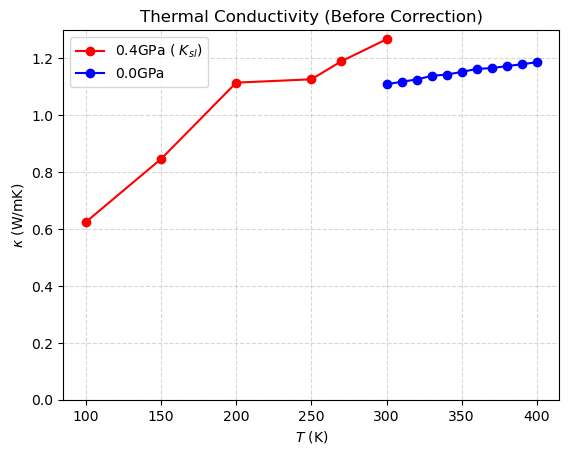

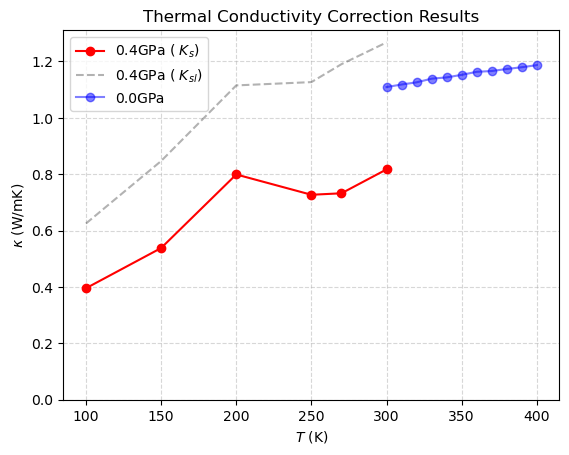

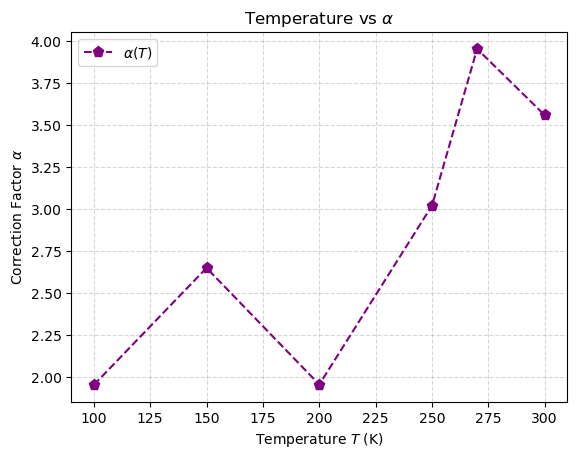

In [8]:
#--------------------------------読み込むデータ--------------------------------
filename_solid = '3w法.xlsx'
filename_liquid = 'FC77 3w法.xlsx'
df_sl = pd.read_excel(filename_solid, sheet_name='解析＿0.4Gpa_glass') # 0.4GPaの固体のデータ
df_l = pd.read_excel(filename_liquid, sheet_name='解析　0.4Gpa_FC77') # 0.4GPaの液体のデータ
df_ex = pd.read_excel(filename_solid, sheet_name='fittingでの解析')  # 0.0GPa固体のデータ
T_sl = (df_sl['温度(0.4Gpa)']).values             # 0.4GPaの固体、液体の温度
K_sl = (df_sl['熱伝導率(0.4Gpa)']).values         # 0.4GPaの固体・液体の熱伝導率
C_sl = (df_sl['体積比熱(0.4Gpa)']).values * 1e6   # 0.4GPaの固体・液体の体積比熱 (J/m^3変換)
T_l = df_l['温度(FC77,0.4Gpa)'].values             # 0.4GPaの液体の温度
K_l = df_l['熱伝導率(FC77,0.4Gpa)'].values         #0.4GPaの液体の熱伝導率
C_l = df_l['体積比熱(FC77,0.4Gpa)'].values * 1e6   # 0.4GPaの液体の体積比熱 (J/m^3変換)

mask_sl = ~np.isnan(T_sl) & ~np.isnan(K_sl) & ~np.isnan(C_sl) 
df_sl = pd.DataFrame({'T': T_sl[mask_sl], 'K_sl': K_sl[mask_sl], 'C_sl': C_sl[mask_sl]}) 
mask_l = ~np.isnan(T_l) & ~np.isnan(K_l) & ~np.isnan(C_l) 
df_l = pd.DataFrame({'T': T_l[mask_l], 'K_l': K_l[mask_l], 'C_l': C_l[mask_l]}) 
df_merged = pd.merge(df_sl, df_l, on='T', how='inner')

#--------------------------------計算で用いる物理量と周波数範囲--------------------------------

b = 5.25 * 10**-5     # 金属膜の幅の半分 [m]
num_freq_points = 10  # 平均をとる周波数の分割数
# 見かけの物質の周波数範囲
freq_min_sl = 30.0
freq_max_sl = 10000.0
# 液体の周波数範囲
freq_min_l = 30.0 
freq_max_l = 10000.0 

# 自分でfreqのデータをlogスケールで等分されるように作成する
freq_array_sl = np.logspace(np.log10(freq_min_sl), np.log10(freq_max_sl), num_freq_points)
freq_array_l = np.logspace(np.log10(freq_min_l), np.log10(freq_max_l), num_freq_points)

print(f"Alpha計算中...")
k_limit = 100.0 / b  
alphas = {} 

for _, row in df_merged.iterrows():
    val_f_sl = (1 / (2 * np.pi)) * (row['K_sl'] / row['C_sl'])
    val_f_l  = (1 / (2 * np.pi)) * (row['K_l'] / row['C_l'])
    
#積分関数を1つだけ作りslでもlでも使い回せるようにする
    def calculate_F_real(q_val):
        """与えられた q に対して無次元変数 phi で積分を行い、実部を返す関数"""
        psi = q_val * b  # 無次元のパラメータ psi を作る        
        def integrand_val(phi):
            if phi < 1e-8: return (1.0 / psi) 
            term = np.sqrt(phi**2 + psi**2)
            return (np.sin(phi)**2) / (phi**2 * term)            
        def integrand_real(phi): return np.real(integrand_val(phi))
        F_real, _ = integrate.quad(integrand_real, 1e-8, np.inf, limit=1000)
        return F_real
# リストに今回のデータを計算された積分を保存
    F_qb_sl = []
    for freq in freq_array_sl:
        q_sl = np.sqrt((2 * freq / val_f_sl) * 1j)
        F_qb_sl.append(calculate_F_real(q_sl))
# リストに今回のデータを計算された積分を保存
    F_qb_l = []
    for freq in freq_array_l:
        q_l = np.sqrt((2 * freq / val_f_l) * 1j)
        F_qb_l.append(calculate_F_real(q_l))       
    #平均を取る
    mean_F_qb_sl = np.mean(F_qb_sl) 
    mean_F_qb_l  = np.mean(F_qb_l)  

    if mean_F_qb_l  != 0:                               # 0で割るのを防ぐ
        alphas[row['T']] = mean_F_qb_sl / mean_F_qb_l 
df_merged['alpha'] = df_merged['T'].map(alphas)
df_merged['K_s'] = df_merged['K_sl'] - (df_merged['alpha'] * df_merged['K_l'])

print("\n=== 最終補正結果 ===")
result_columns = ['T', 'K_sl', 'K_l', 'alpha', 'K_s']
print(df_merged[result_columns].to_string(index=False))
#--------------------------------圧力をかけていない時のデータ--------------------------------

T_0 = df_ex['温度(0.0Gpa,glass)'].values
K_0 = df_ex['熱伝導率(0.0Gpa,glass)'].values

mask_0 = ~np.isnan(T_0) & ~np.isnan(K_0)
T_0, K_0 = T_0[mask_0], K_0[mask_0]



plt.plot(df_merged['T'], df_merged['K_sl'], 'ro-', label='0.4GPa ( $K_{sl}$)')
plt.plot(T_0, K_0, 'bo-', label='0.0GPa') 
plt.xlabel("$T$ (K)")
plt.ylabel("$\kappa$ (W/mK)")
plt.title("Thermal Conductivity (Before Correction)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(bottom=0) # グラフの底を0に固定
plt.show()

plt.plot(df_merged['T'], df_merged['K_s'], 'ro-', label='0.4GPa ( $K_s$)') 
plt.plot(df_merged['T'], df_merged['K_sl'], 'k--', alpha=0.3, label='0.4GPa ( $K_{sl}$)')
plt.plot(T_0, K_0, 'bo-', alpha=0.5, label='0.0GPa') 
plt.xlabel("$T$ (K)")
plt.ylabel("$\kappa$ (W/mK)")
plt.title("Thermal Conductivity Correction Results")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(bottom=0)
plt.show()

plt.plot(df_merged['T'], df_merged['alpha'], 'p--', color='purple', markersize=8, label=r'$\alpha(T)$') 
plt.xlabel('Temperature $T$ (K)')
plt.ylabel(r'Correction Factor $\alpha$')
plt.title('Temperature vs $\\alpha$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()